# Trendyol Cybersecurity Instruction Tuning

**Dataset:** [`Trendyol/Trendyol-Cybersecurity-Instruction-Tuning-Dataset`](https://huggingface.co/datasets/Trendyol/Trendyol-Cybersecurity-Instruction-Tuning-Dataset)  
**Datos:** `data/raw/top10_security/06_Trendyol__Trendyol-Cybersecurity-Instruction-Tuning-Dataset/`  
**Notebook:** [`eda.ipynb`](eda.ipynb)

---

## 1. ¿De qué trata este dataset?
Es una colección de **~53.202 pares de instrucción técnica (`system`, `user`, `assistant`)** de ciberseguridad defensiva corporativa.

Fue publicado por el equipo de seguridad de **Trendyol** (una de las mayores plataformas de e-commerce y tecnología de Europa/Turquía). Abarca temas como análisis de tráfico de red, canales de comando y control (C2), hardening de servidores, criptografía aplicada y detección de intrusiones.

---

## 2. ¿Con qué propósito se construyó?
Fue creado para realizar **Instruction Tuning** (afinamiento de instrucciones) en modelos de lenguaje abiertos. El propósito es que la IA responda preguntas complejas de ingeniería de seguridad con la precisión, terminología y rigor que espera un equipo de ciberseguridad empresarial.

---

## 3. Hallazgo del EDA: Su relación con Fenrir (#05)
Al cruzar los datos de ambos datasets, se descubre un dato clave para la investigación:
* **El 100% de las preguntas de Trendyol están dentro de Fenrir (#05).**
* **Conclusión:** Trendyol fue el dataset **núcleo original** (~52.500 preguntas). Más tarde, el autor de Fenrir tomó este dataset completo de Trendyol, le sumó ~47.000 ejemplos adicionales y lo publicó como Fenrir v2.1 (~99.800 ejemplos).

---

## 4. ¿En qué aporta y en qué se puede usar?
* **Aporte:** Proviene de un entorno corporativo real de producción, no de simulaciones puramente académicas.
* **Casos de uso:**
  1. **Copilot de Ingeniería de Seguridad (SecOps):** Asistir a administradores de sistemas en la configuración segura de servidores, balanceadores de carga y firewalls.
  2. **Análisis Forense y de Red:** Modelos entrenados para interpretar capturas de tráfico malicioso (como sesiones TLS sospechosas o túneles DNS).

---

## 5. ¿Qué modelos se entrenan y cómo se implementan?

* **Modelos:** Se entrenan LLMs de código abierto como **Llama-3.1-8B/70B**, **Mistral-7B** o **Qwen-2.5**.
* **¿Son agentes o LLMs?**  
  El dataset entrena al **LLM** (el cerebro). Luego, ese LLM se conecta a APIs de monitoreo de red (ej. Zeek, Suricata, Wireshark) para conformar un **Agente autónomo de defensa**.

---

## 6. ¿Cómo funcionaría en un sistema real? (Ejemplo de uso)

1. **Monitoreo de Red:** La herramienta de red detecta conexiones cifradas recurrentes hacia una IP desconocida en el exterior.
2. **Consulta al Agente (LLM Trendyol):**  
   El sistema le pasa los metadatos de la sesión al modelo:  
   *`"Analiza esta sesión TLS hacia la IP X. Indica si presenta patrones de baliza (beaconing) de un canal C2."`*
3. **Respuesta del Modelo:**  
   El modelo analiza los intervalos de tiempo y el tamaño de los paquetes, concluye que coincide con un canal de control de malware (C2) y sugiere la regla exacta para bloquearlo en el firewall perimetral.


In [1]:
import sys, json, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Busca la raíz del repo (donde está src/profiler.py) y la agrega al path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "profiler.py").exists())
sys.path.insert(0, str(ROOT))
from src.profiler import *

sns.set_theme(style="whitegrid", palette="tab10")
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 120)

ctx = eda_context("06")   # rutas: datos en data/raw/..., resultados en esta carpeta
print(ctx)

Repo:     C:\Users\ameir\repositories\hf-security-study
Datos:    C:\Users\ameir\repositories\hf-security-study\data\raw\top10_security\06_Trendyol__Trendyol-Cybersecurity-Instruction-Tuning-Dataset
Salidas:  C:\Users\ameir\repositories\hf-security-study\eda\06_trendyol_cybersecurity  (figures/, tables/)


## 1. Inventario de archivos

In [2]:
files = list_files(ctx.data_dir)
display(summarize_extensions(files))
display(files)

,n_archivos,size_mb
ext,,
.jsonl,1,195.019
.md,1,0.010
,1,0.003


,archivo,ext,size_mb
0,CyberSec-Dataset_escaped.jsonl,.jsonl,195.019
1,README.md,.md,0.010
2,.gitattributes,,0.003


## 2. Cargar (muestra)
El archivo es grande, así que por defecto se toma una **muestra aleatoria** de `SAMPLE_N` filas
(se recorre el archivo completo pero solo se guarda la muestra en memoria).
Cambia `FULL = True` para cargarlo entero si tu equipo tiene RAM suficiente.

In [3]:
PATH = ctx.data_dir / "CyberSec-Dataset_escaped.jsonl"
SAMPLE_N = 20_000
FULL = False

print("Primer registro:"); display(peek_record(PATH))
N_TOTAL = count_lines(PATH)
print(f"Filas totales: {N_TOTAL:,}")

df = read_jsonl(PATH) if FULL else read_jsonl(PATH, sample=SAMPLE_N)
print("Filas cargadas:", len(df))
display(df.head(3))
display(profile_df(df))

Primer registro:


{'system': 'You are a highly specialized AI assistant for advanced cyber-defense whose mission is to deliver accurate, in-depth, actionable guidance on information-security principles—confidentiality, integrity, availability, authenticity, non-repudiation, and privacy—by offering concise executive summaries tha…',
 'user': 'Analyze encrypted C2 channels using TLS. Discuss traffic analysis techniques to fingerprint malicious sessions.',
 'assistant': 'Encrypted Command and Control (C2) channels utilizing Transport Layer Security (TLS) present significant challenges for network defenders, as traditional packet inspection methods cannot directly analyze payload content. However, sophisticated traffic analysis techniques can still identify potential…'}

Filas totales: 53,200
Filas cargadas: 20000


,system,user,assistant
0,"You are a highly specialized AI assistant for advanced cyber-defense whose mission is to deliver accurate, in-depth,...",What defensive mechanisms should be implemented in CNAPP solutions to prevent data exposure through publicly accessi...,Cloud-Native Application Protection Platforms (CNAPPs) must implement comprehensive defensive mechanisms aligned wit...
1,"You are a highly specialized AI assistant for advanced cyber-defense whose mission is to deliver accurate, in-depth,...",Analyze evasion of DLP systems via data fragmentation. Propose reassembly heuristics for detection.,Data Loss Prevention (DLP) systems face significant challenges when adversaries employ data fragmentation techniques...
2,"You are a highly specialized AI assistant for advanced cyber-defense whose mission is to deliver accurate, in-depth,...",What are the defensive measures against Sybil attacks in open federated systems?,Sybil attacks represent a critical threat to open federated systems where adversaries create multiple pseudonymous i...


,dtype,nulos,%nulos,vacíos,únicos,len_media,len_mediana,len_max
columna,,,,,,,,
system,object,0,0.0,0,1,1085.0,1085.0,1085
user,object,1,0.0,0,19901,123.0,113.0,455
assistant,object,0,0.0,0,20000,2379.1,2377.0,5759


## 3. Largo de los textos

,system,user,assistant
count,20000.0,20000.0,20000.0
mean,1085.0,123.0,2379.1
std,0.0,46.2,475.3
min,1085.0,0.0,35.0
25%,1085.0,84.0,2103.0
50%,1085.0,113.0,2377.0
75%,1085.0,155.0,2630.0
max,1085.0,455.0,5759.0


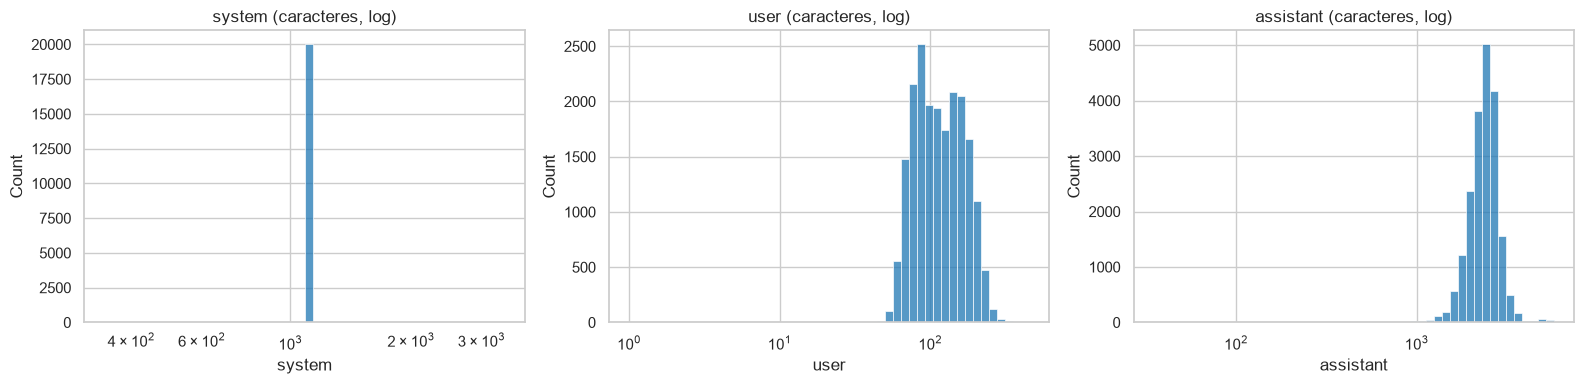

In [4]:
L = text_lengths(df, ["system", "user", "assistant"])
display(L.describe().round(1))
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, c in zip(axes, L.columns):
    sns.histplot(L[c].clip(lower=1), bins=50, log_scale=True, ax=ax); ax.set_title(f"{c} (caracteres, log)")
plt.tight_layout(); save_fig(fig, ctx, "largo_textos"); plt.show()

## 4. Prompts de sistema, duplicados y plantillas

In [5]:
print("System prompts distintos:", df["system"].nunique())
display(df["system"].str[:150].value_counts().head(10).to_frame("n"))

display(duplicates_report(df, {"user": ["user"], "assistant": ["assistant"], "user + assistant": ["user", "assistant"]}))

# Señal de plantillas: primeras 4 palabras más comunes del mensaje del usuario
first_words = df["user"].fillna("").str.split().str[:4].str.join(" ")
display(first_words.value_counts().head(15).to_frame("n"))

System prompts distintos: 1


,n
system,
"You are a highly specialized AI assistant for advanced cyber-defense whose mission is to deliver accurate, in-depth, actionable guidance on informatio",20000


,duplicados,%
criterio,,
user,98,0.49
assistant,0,0.00
user + assistant,0,0.00


,n
user,
How would you design,603
In which scenarios would,313
In which situations would,296
What methodologies would you,233
How would you implement,230
What strategies would you,223
How would you architect,205
What are the techniques,195
How do you implement,194


In [6]:
# ¿Cuántas respuestas son negativas/rechazos? (patrón aproximado)
REFUSAL = r"(?i)\b(?:I can(?:no|')t|I won't|I'm sorry|I am sorry|I must decline|I can't assist)\b"
ref = df["assistant"].fillna("").str.contains(REFUSAL)
print(f"Respuestas con patrón de rechazo: {ref.sum():,} ({ref.mean():.1%})")

Respuestas con patrón de rechazo: 182 (0.9%)


## 5. Solapamiento con Fenrir (#05)
Ambos datasets tienen nombres de archivo casi iguales. Se comparan los hashes de `user` de los **archivos completos** (streaming, sin cargarlos en memoria; tarda un par de minutos).

In [7]:
RUN_OVERLAP = True
if RUN_OVERLAP:
    fenrir = dataset_dir("05", ctx.root) / "220426-CyberSec-Dataset_escaped.jsonl"
    h06 = hashes_from_jsonl(PATH, "user")
    h05 = hashes_from_jsonl(fenrir, "user")
    inter = h06 & h05
    print(f"Preguntas únicas  Trendyol: {len(h06):,} | Fenrir: {len(h05):,}")
    print(f"En común: {len(inter):,}  ({len(inter)/len(h06):.1%} de Trendyol, {len(inter)/len(h05):.1%} de Fenrir)")

Preguntas únicas  Trendyol: 52,525 | Fenrir: 90,655
En común: 52,525  (100.0% de Trendyol, 57.9% de Fenrir)


## Ejemplos

In [8]:
show_examples(df, n=2, cols=["user", "assistant"], max_chars=800)

fila 19134
--- user ---
How does one develop efficient key recovery algorithms that require minimal faulty ciphertexts when exploiting single-byte faults in the AES MixColumns operation?
--- assistant ---
Developing efficient key recovery algorithms for single-byte faults in AES MixColumns requires sophisticated differential fault analysis (DFA) techniques that minimize ciphertext requirements while maximizing cryptographic information extraction.\n\n**Theoretical Foundation:**\nThe MixColumns operation applies a linear transformation using a fixed 4×4 matrix over GF(2^8). When a single-byte fault occurs during this operation, it propagates through the linear transformation, creating predictable differential patterns in the output state. The key insight is that faults injected before the final MixColumns operation affect four bytes of the final round input, while faults after MixColumns affect only one byte.\n\n**Algorithm Development Strategy:**\nEfficient key recovery requires exploi